In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

ROOT = Path("..")

PROCESSED_PATH = (
    ROOT
    / "data"
    / "processed"
)

MODEL_PATH = (
    ROOT
    / "models"
    / "best_model.pkl"
)

REPORT_PATH = (
    ROOT
    / "reports"
)

FIGURE_PATH = (
    REPORT_PATH
    / "figures"
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)

test = pd.read_csv(
    PROCESSED_PATH / "test.csv"
)

model = joblib.load(
    MODEL_PATH
)

print(
    "Test dataset:",
    test.shape
)

Test dataset: (1000, 13)


In [2]:
X_test = test.drop(
    columns=["disruption"]
)

y_test = test["disruption"].astype(int)

prediction = model.predict(
    X_test
)

probability = (
    model
    .predict_proba(X_test)[:, 1]
)

In [3]:
accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    probability
)

final_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

for metric, value in final_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )

Accuracy: 0.7210
Precision: 0.7752
Recall: 0.7663
F1: 0.7707
ROC_AUC: 0.8124


In [4]:
print(
    classification_report(
        y_test,
        prediction,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.6380    0.6495    0.6437       388
           1     0.7752    0.7663    0.7707       612

    accuracy                         0.7210      1000
   macro avg     0.7066    0.7079    0.7072      1000
weighted avg     0.7220    0.7210    0.7214      1000



In [5]:
final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df.to_csv(
    REPORT_PATH / "final_metrics.csv",
    index=False
)

print(
    "Final metrics saved."
)

Final metrics saved.


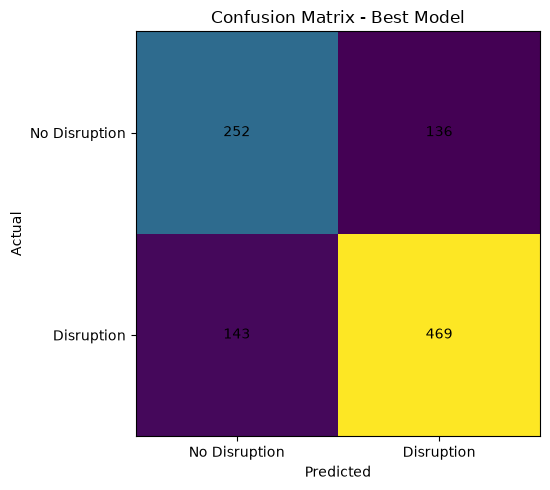

In [6]:
cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm
)

plt.title(
    "Confusion Matrix - Best Model"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    [
        "No Disruption",
        "Disruption"
    ]
)

plt.yticks(
    [0, 1],
    [
        "No Disruption",
        "Disruption"
    ]
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "confusion_matrix.png",
    dpi=200
)

plt.show()

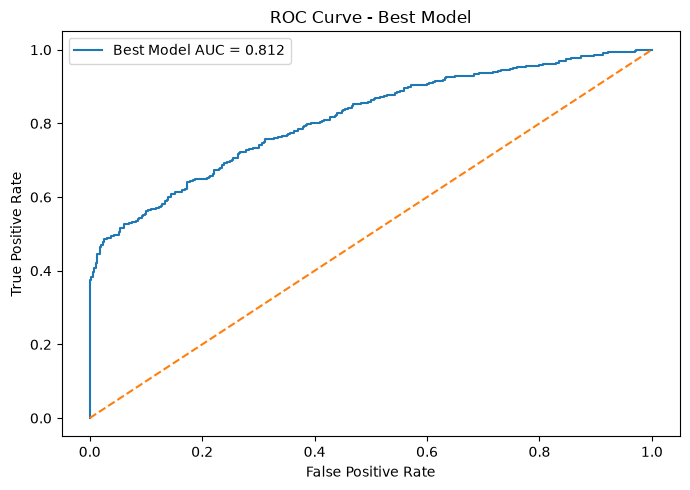

In [7]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    probability
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Best Model AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Best Model"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "roc_curve.png",
    dpi=200
)

plt.show()